# K-Prototypes

In [ ]:
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
import umap

# Load data
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop columns that dont contribute to clustering
# - S.No.: just an index
# - 'Year': not much variation as seen in EDA plot
# - 'Month': not much variation as seen in EDA plot
# - 'Date': cannot process date time feature
# - 'Hispanic': no information provided on what the values mean
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

## Feature Engineering

In [ ]:
encoded_categorical = [
    # Incident type (4 categories)
    'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined',

    # Education level (5 categories)
    'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 
    'Education_Some college', 'Education_Unknown'

    # Gender (2 categories)
    'Sex_Female', 'Sex_Male',

    # Race (5 categories)
    'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 
    'Race_Native American/Native Alaskan', 'Race_White',

    # Location of incident (11 categories)
    'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction',
    'Place of incident_Other specified', 'Place of incident_Other unspecified', 
    'Place of incident_Residential institution', 'Place of incident_School/instiution',
    'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area',
    'Place of incident_Unspecified',

    # Temporal features
    'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 
    'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
    'isWeekend' ,

    # Other binary features
    'Police involvement'     
]

num_features = ["Age"]

## Data Preparation

To create clustering dataset with the features above

In [ ]:
all_features = encoded_categorical + num_features
df_cluster = df[all_features].copy()

# Preprocessor for evaluation metrics
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])
pre = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", "passthrough", encoded_categorical)
], remainder="drop")

# Prepare K-Prototypes data
# K-Prototypes requires numerical features FIRST, then categorical
ordered_cols = num_features + encoded_categorical
X_kproto = df_cluster[ordered_cols].values

# Impute missing Age values
# just for completeness, although missing values handled in data cleaning
age_imputer = SimpleImputer(strategy='median')
X_kproto[:, :len(num_features)] = age_imputer.fit_transform(X_kproto[:, :len(num_features)])

categorical_indices = list(range(len(num_features), X_kproto.shape[1]))

print(f"Data shape: {X_kproto.shape}")
print(f"Numerical features: {len(num_features)}, Categorical features: {len(encoded_categorical)}")

Data shape: (100798, 37)
Numerical features: 1, Categorical features: 36


## Helper Functions

In [ ]:
def prop_table(data, col):
    """
    Create proportion table for a categorical variable
    Shows the distribution of each category within each cluster as proportions.
    """
    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

def create_cluster_profile(df, labels):
    """
    Create full cluster profile from labels
    - decodes one-hot encoded features back to original categories
    - creates numerical summaries (count, mean, median for Age)
    - creates categoricaal summaries (proportions for all categorical variables)
    
    """
    df_summary = df.copy()
    df_summary["cluster"] = labels
    
    # Decode one-hot encoded features
    df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
    df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
    df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
    df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
    df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
    df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')
    df_summary["Police_involvement"] = df_summary["Police involvement"].map({0: "No", 1: "Yes"})
    df_summary["Weekend"] = df_summary["isWeekend"].map({0: "Weekday", 1: "Weekend"})
    
    # Create summaries
    num_summary = df_summary.groupby("cluster")[["Age"]].agg(["count", "mean", "median"]).round(2)
    
    cat_summary = pd.concat([
        prop_table(df_summary, "Race"),
        prop_table(df_summary, "Education"),
        prop_table(df_summary, "Place_of_incident"),
        prop_table(df_summary, "Reason"),
        prop_table(df_summary, "Day_of_week"),
        prop_table(df_summary, "Sex"),
        prop_table(df_summary, "Police_involvement"),
        prop_table(df_summary, "Weekend") 
    ], axis=1)
    
    return df_summary, num_summary, cat_summary

def print_cluster_profile(k, num_summary, cat_summary, df_summary):
    """Print formatted cluster profile"""
    cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()
    
    print("\n" + "="*70)
    print(f"CLUSTER PROFILE FOR K={k}")
    print("="*70)
    
    # Cluster sizes
    print("\n1. CLUSTER SIZES")
    print("-" * 50)
    for cluster, size in df_summary['cluster'].value_counts().sort_index().items():
        print(f"Cluster {cluster}: {size:>6,} ({size/len(df_summary)*100:>5.1f}%)")
    
    # Print each distribution
    sections = [
        ("2. AGE DISTRIBUTION", num_summary[['Age']]),
        ("3. POLICE INVOLVEMENT", cluster_profile.filter(like='Police_involvement=')),
        ("4. WEEKEND", cluster_profile.filter(like='Weekend=')),
        ("5. RACE", cluster_profile.filter(like='Race=')),
        ("6. EDUCATION", cluster_profile.filter(like='Education=')),
        ("7. PLACE OF INCIDENT", cluster_profile.filter(like='Place_of_incident=')),
        ("8. REASON", cluster_profile.filter(like='Reason=')),
        ("9. DAY OF WEEK", cluster_profile.filter(like='Day_of_week=')),
        ("10. SEX", cluster_profile.filter(like='Sex='))
    ]
    
    for title, data in sections:
        print(f"\n{title}")
        print("-" * 50)
        print(data)
    
    print("\n" + "="*70)
    return cluster_profile

def run_kprototypes_analysis(k, X_kproto, categorical_indices, df, df_cluster, pre, 
                              n_init=10, verbose=2, plot_umap=True):
    """
    Run complete K-Prototypes analysis for a given K
    
    1. fits K-Prototypes model
    2. computes evaluation metrics (cost, Davies-Bouldin, Calinski-Harabasz, Silhouette)
    3. creates silhouette plot
    4. creates UMAP visualization
    5. generates cluster profiles

    Parameters:
    k: number of clusters
    X_kproto: dataset with the features
    categorical_indices: indices of categorical columns
    df: original dataframe
    df_cluster: clustering dataframe
    pre: preprocessor for evaluation mettrics
    n_init: number of random initializations
    verbose: controls how much info the algorithm prints, 0 to print nothing, 2 to print in detail
    plot_umap: whether to create UMAP visualization or not
    
    returns:
    labels, kproto, cluster_profile, cat_summary, silhouette_avg
    """
    from sklearn.metrics import silhouette_score, silhouette_samples
    
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR K={k}")
    print(f"{'='*60}")
    
    # Fit model
    kproto = KPrototypes(n_clusters=k, 
                         init='Huang', # selects initial centroids by choosing first point randomly
                                       # then select subsequent centroids to maximize dissimilarity from previously chosen ones.
                         random_state=3244, 
                         verbose=verbose, 
                         n_init=n_init)
    labels = kproto.fit_predict(X_kproto, categorical=categorical_indices)
    
    # Cluster distribution
    print(f"\nCluster distribution:")
    for cluster_id, count in zip(*np.unique(labels, return_counts=True)):
        print(f"  Cluster {cluster_id}: {count} ({count/len(labels)*100:.1f}%)")
    
    # Evaluation metrics (including silhouette)
    df_pre = pre.fit_transform(df_cluster)
    silhouette_avg = silhouette_score(df_pre, labels)
    sample_scores = silhouette_samples(df_pre, labels)
    
    print(f"\nEVALUATION METRICS:")
    print(f"  Cost: {kproto.cost_:.2f}")
    print(f"  Davies-Bouldin: {davies_bouldin_score(df_pre, labels):.4f} (lower=better)")
    print(f"  Calinski-Harabasz: {calinski_harabasz_score(df_pre, labels):.2f} (higher=better)")
    print(f"  Silhouette: {silhouette_avg:.4f} (higher=better)")
    
    # Per-cluster silhouette breakdown
    print(f"\n  Per-Cluster Silhouette:")
    for cluster in range(k):
        cluster_scores = sample_scores[labels == cluster]
        n_negative = (cluster_scores < 0).sum()
        print(f"    Cluster {cluster}: mean={cluster_scores.mean():.4f}, "
              f"negative={n_negative} ({n_negative/len(cluster_scores)*100:.1f}%)")
    
    # Silhouette plot
    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    
    for cluster in range(k):
        cluster_scores = sample_scores[labels == cluster]
        cluster_scores.sort()
        
        y_upper = y_lower + len(cluster_scores)
        color = plt.cm.tab10(cluster / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_scores), str(cluster))
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", 
               label=f'Average: {silhouette_avg:.3f}')
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(f"Silhouette Plot for K={k}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # UMAP visualization
    if plot_umap:
        reducer = umap.UMAP(n_components=2, metric='euclidean', n_neighbors=30, 
                           min_dist=0.1, random_state=3244)
        print("\nFitting UMAP...")
        X_2d = reducer.fit_transform(df_pre)
        
        plt.figure(figsize=(10, 8))
        for c in sorted(np.unique(labels)):
            mask = labels == c
            plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.5, label=f"Cluster {c}")
        plt.legend(markerscale=3)
        plt.title(f"UMAP Projection (K={k})")
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.tight_layout()
        plt.show()
    
    # Cluster profile
    df_summary, num_summary, cat_summary = create_cluster_profile(df, labels)
    cluster_profile = print_cluster_profile(k, num_summary, cat_summary, df_summary)
    
    return labels, kproto, cluster_profile, cat_summary, silhouette_avg

## Elbow Method

to determine the optimal number of clusters


Finding optimal K...
Testing K=2... Cost: 15346666.17
Testing K=3... Cost: 9492698.08
Testing K=4... Cost: 7437457.00
Testing K=5... Cost: 6466673.32
Testing K=6... Cost: 5933172.23
Testing K=7... Cost: 5574939.47
Testing K=8... Cost: 5305746.57
Testing K=9... Cost: 5020137.12
Testing K=10... Cost: 4832883.84


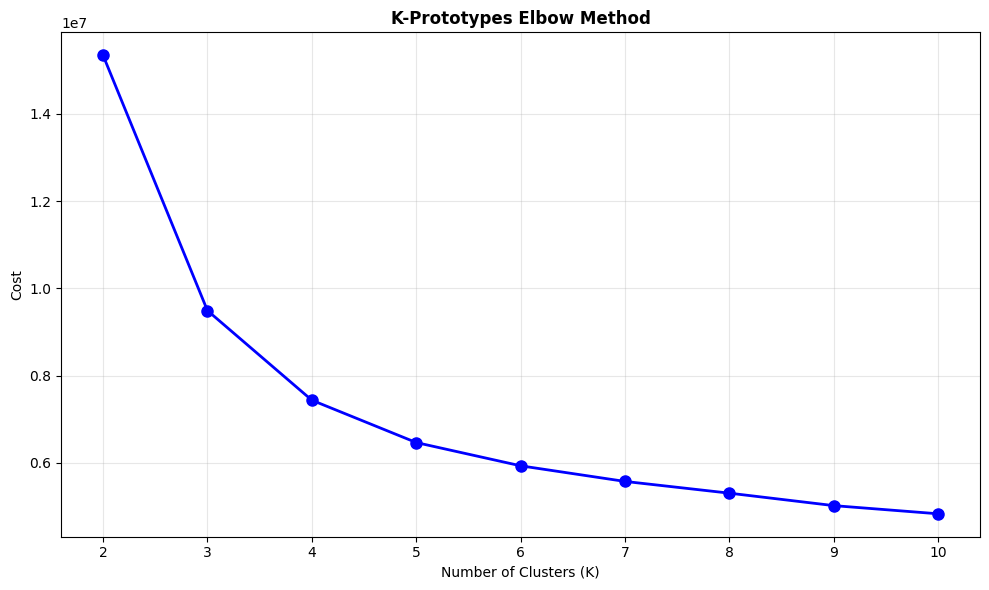

In [ ]:
costs = []
K_range = range(2, 11)

print("\nFinding optimal K...")
for k in K_range:
    print(f"Testing K={k}...", end=" ")
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=3244, verbose=0, n_init=5)
    kproto.fit(X_kproto, categorical=categorical_indices)
    # objective function to minimize, 
    # measures how well the clusters fit the data by calculating the total dist of points to centroids
    # euclidean distance for numerical features, and matching dissimilarity for categorical features
    costs.append(kproto.cost_) 
    print(f"Cost: {kproto.cost_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost')
plt.title('K-Prototypes Elbow Method', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

From the elbow plot, we see that the optimal number of clusters, determined by the elbow point is either k=4 or k=5

## k = 4


ANALYSIS FOR K=4
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 27848, ncost: 8639004.145741679
Run: 1, iteration: 2/100, moves: 11581, ncost: 8016168.573570898
Run: 1, iteration: 3/100, moves: 7411, ncost: 7790989.915331657
Run: 1, iteration: 4/100, moves: 5541, ncost: 7666527.790958659
Run: 1, iteration: 5/100, moves: 4245, ncost: 7594380.939913698
Run: 1, iteration: 6/100, moves: 3811, ncost: 7534699.970798528
Run: 1, iteration: 7/100, moves: 3175, ncost: 7491318.03694777
Run: 1, iteration: 8/100, moves: 2021, ncost: 7473659.60277574
Run: 1, iteration: 9/100, moves: 1724, ncost: 7461053.698058376
Run: 1, iteration: 10/100, moves: 106, ncost: 7460999.476160716
Run: 1, iteration: 11/100, moves: 0, ncost: 7460999.476160716
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 21317, ncost: 7690188.503824771
Run: 2, iteration: 2/100, moves: 7762, ncost: 7466878.2

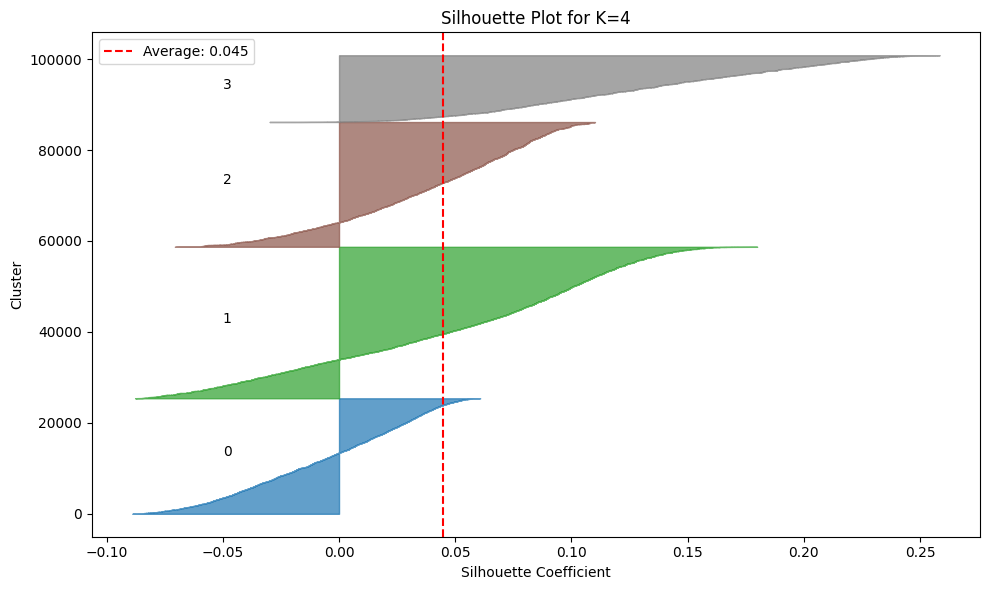


Fitting UMAP...


C:\Users\Beckh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


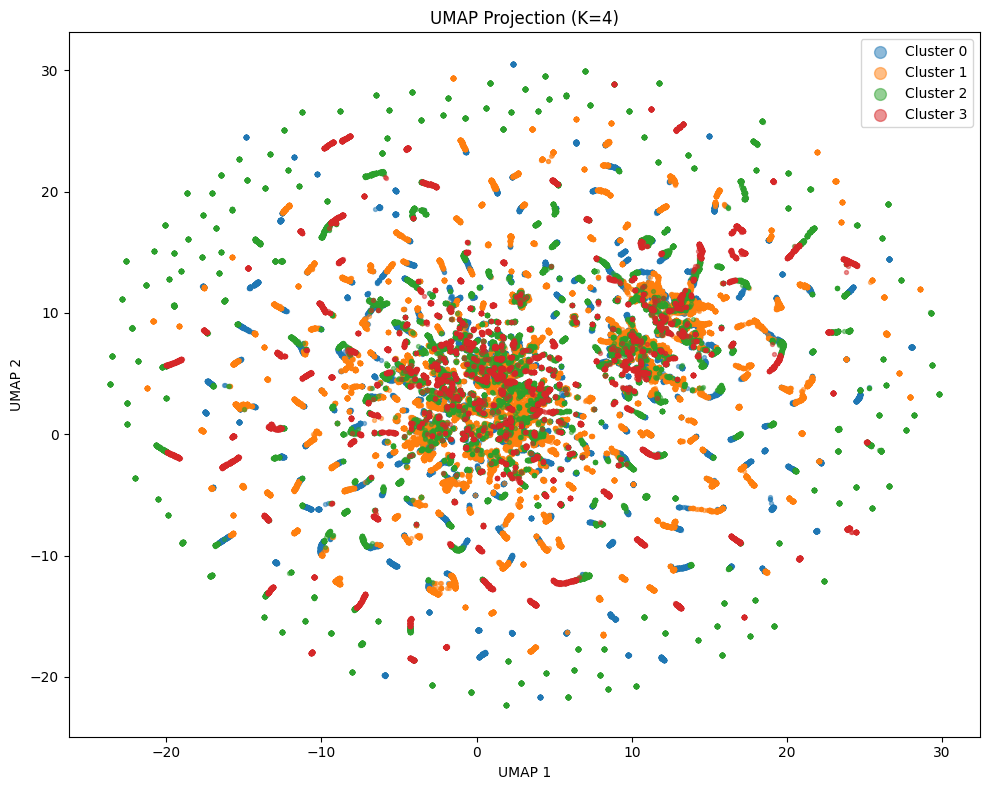


CLUSTER PROFILE FOR K=4

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 25,397 ( 25.2%)
Cluster 1: 33,301 ( 33.0%)
Cluster 2: 27,429 ( 27.2%)
Cluster 3: 14,671 ( 14.6%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        25397  39.90   40.0
1        33301  23.97   24.0
2        27429  57.09   57.0
3        14671  77.97   77.0

3. POLICE INVOLVEMENT
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.981                   0.019
1                        0.981                   0.019
2                        0.991                   0.009
3                        0.998                   0.002

4. WEEKEND
--------------------------------------------------
         Weekend=Weekday  Weekend=Weekend
cluster       

In [23]:
labels_4, model_4, profile_4, cat_4, sil_4 = run_kprototypes_analysis(
    k=4, X_kproto=X_kproto, categorical_indices=categorical_indices,
    df=df, df_cluster=df_cluster, pre=pre
)

## k = 5


ANALYSIS FOR K=5
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 16991, ncost: 6638802.483601897
Run: 1, iteration: 2/100, moves: 4865, ncost: 6596929.635696424
Run: 1, iteration: 3/100, moves: 3260, ncost: 6563740.949579108
Run: 1, iteration: 4/100, moves: 2525, ncost: 6545774.426448621
Run: 1, iteration: 5/100, moves: 3358, ncost: 6516473.23678001
Run: 1, iteration: 6/100, moves: 1351, ncost: 6511911.574371378
Run: 1, iteration: 7/100, moves: 0, ncost: 6511911.574371378
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 28301, ncost: 7147738.904941744
Run: 2, iteration: 2/100, moves: 15339, ncost: 6664163.120048311
Run: 2, iteration: 3/100, moves: 7140, ncost: 6544846.732265332
Run: 2, iteration: 4/100, moves: 3679, ncost: 6503480.727298642
Run: 2, iteration: 5/100, moves: 541, ncost: 6502792.946307302
Run: 2, iteration: 6/100, moves: 0, ncost: 6502792.94630

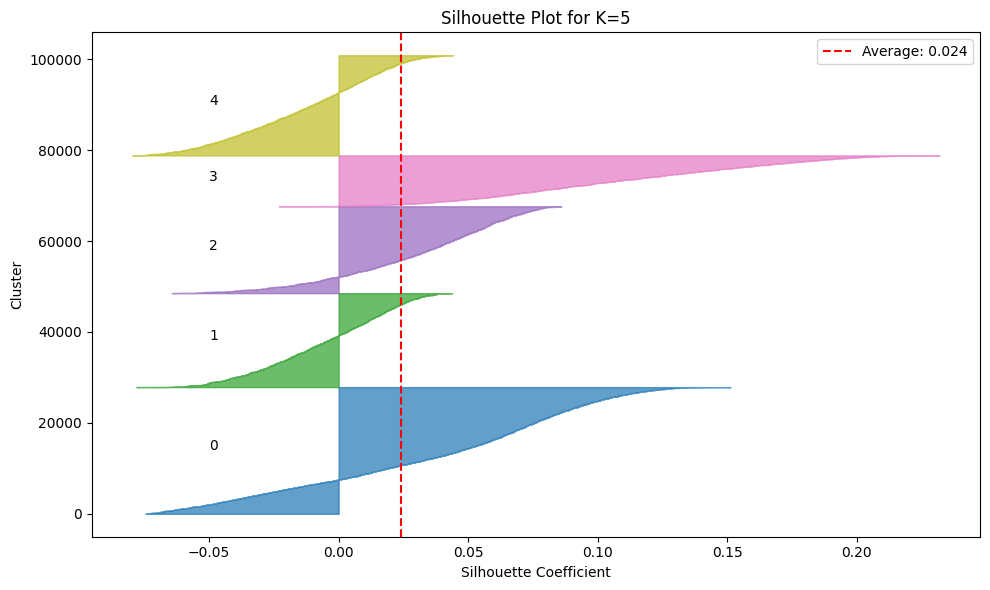


Fitting UMAP...


C:\Users\Beckh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


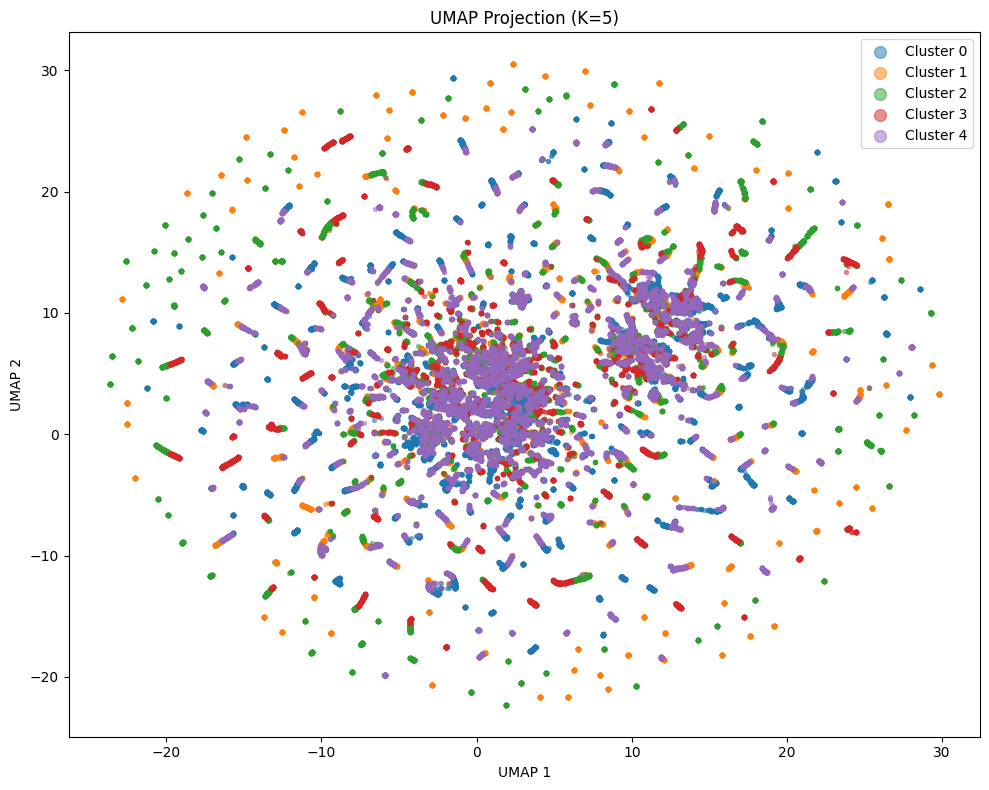


CLUSTER PROFILE FOR K=5

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 27,854 ( 27.6%)
Cluster 1: 20,653 ( 20.5%)
Cluster 2: 19,098 ( 18.9%)
Cluster 3: 11,176 ( 11.1%)
Cluster 4: 22,017 ( 21.8%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        27854  22.69   23.0
1        20653  49.23   49.0
2        19098  62.50   62.0
3        11176  80.62   80.0
4        22017  35.34   35.0

3. POLICE INVOLVEMENT
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.982                   0.018
1                        0.986                   0.014
2                        0.994                   0.006
3                        0.999                   0.001
4                        0.979                   0.021

4. WEEK

In [24]:
labels_5, model_5, profile_5, cat_5, sil_5 = run_kprototypes_analysis(
    k=5, X_kproto=X_kproto, categorical_indices=categorical_indices,
    df=df, df_cluster=df_cluster, pre=pre
)

## Heatmap

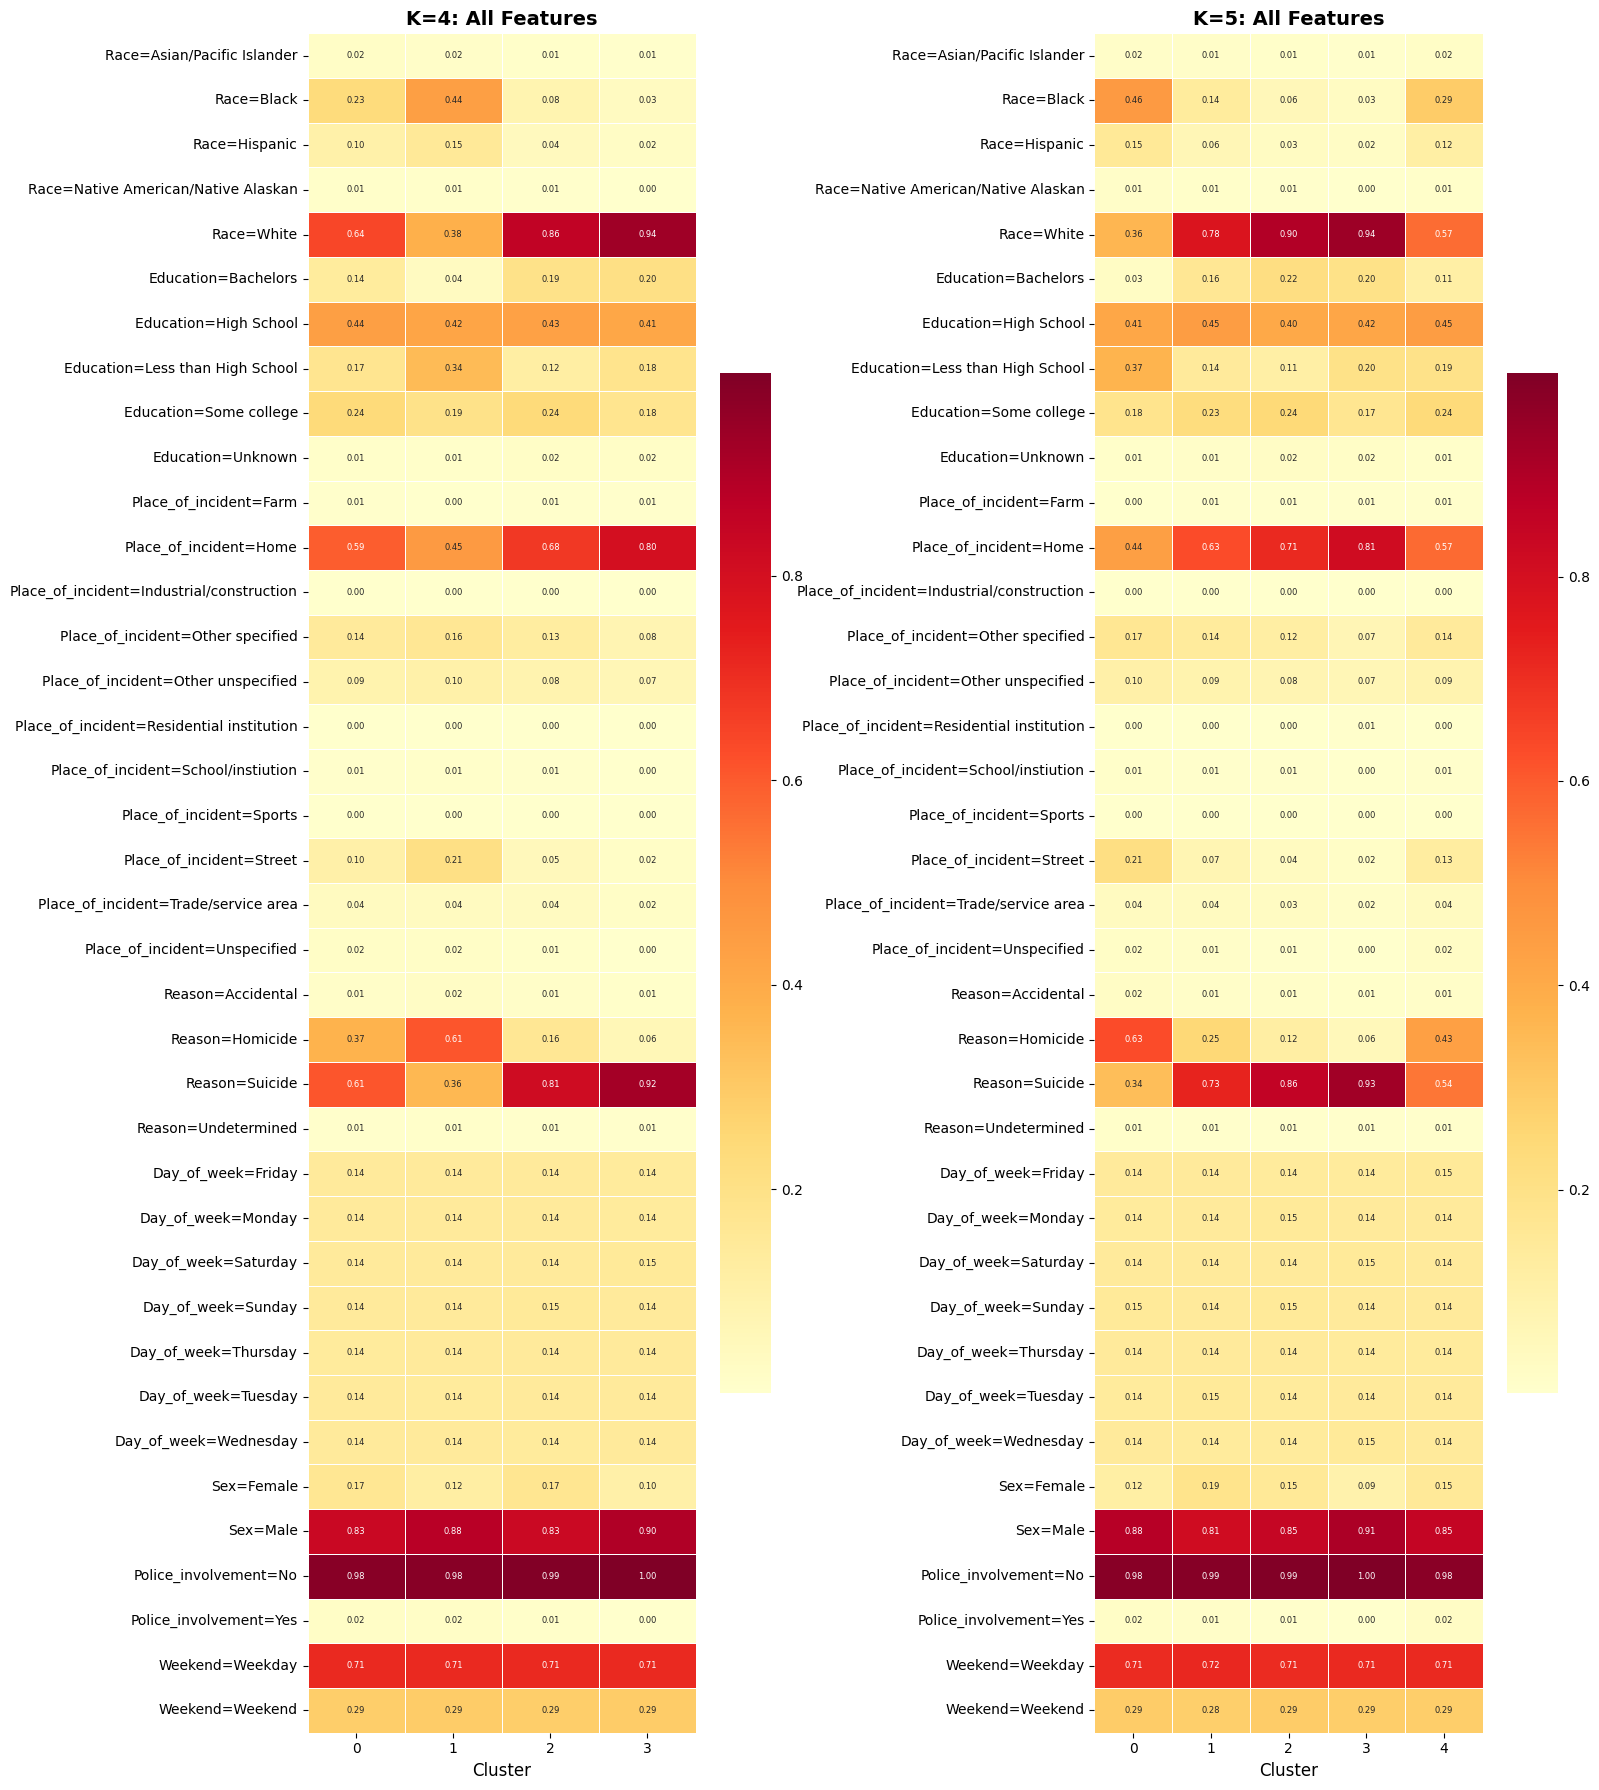

In [ ]:
# Truly all features
fig, axes = plt.subplots(1, 2, figsize=(16, 18))

# K=4
sns.heatmap(cat_4.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[0], annot_kws={'size': 6},
            cbar_kws={'shrink': 0.6})
axes[0].set_title('K=4: All Features', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('')

# K=5
sns.heatmap(cat_5.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[1], annot_kws={'size': 6},
            cbar_kws={'shrink': 0.6})
axes[1].set_title('K=5: All Features', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [26]:
# Cross-tabulation
print("\n" + "="*60)
print("K=4 vs K=5 CROSS-TABULATION")
print("="*60)
print(pd.crosstab(labels_4, labels_5, rownames=['K=4'], colnames=['K=5']))

# Summary comparison
print(f"\n{'='*60}")
print("SUMMARY COMPARISON")
print(f"{'='*60}")
print(f"{'Metric':<25} {'K=4':>12} {'K=5':>12} {'Better':>10}")
print("-" * 60)
print(f"{'Cost':<25} {model_4.cost_:>12.2f} {model_5.cost_:>12.2f} {'K=5':>10}")
db_4 = davies_bouldin_score(pre.fit_transform(df_cluster), labels_4)
db_5 = davies_bouldin_score(pre.fit_transform(df_cluster), labels_5)
ch_4 = calinski_harabasz_score(pre.fit_transform(df_cluster), labels_4)
ch_5 = calinski_harabasz_score(pre.fit_transform(df_cluster), labels_5)
print(f"{'Davies-Bouldin':<25} {db_4:>12.4f} {db_5:>12.4f} {'K=4' if db_4 < db_5 else 'K=5':>10}")
print(f"{'Calinski-Harabasz':<25} {ch_4:>12.2f} {ch_5:>12.2f} {'K=4' if ch_4 > ch_5 else 'K=5':>10}")
print(f"{'Silhouette':<25} {sil_4:>12.4f} {sil_5:>12.4f} {'K=4' if sil_4 > sil_5 else 'K=5':>10}")


K=4 vs K=5 CROSS-TABULATION
K=5      0      1      2      3      4
K=4                                   
0        0   8827      0      0  16570
1    27854      0      0      0   5447
2        0  11826  15603      0      0
3        0      0   3495  11176      0

SUMMARY COMPARISON
Metric                             K=4          K=5     Better
------------------------------------------------------------
Cost                        7426899.74   6463255.56        K=5
Davies-Bouldin                  3.6642       4.5651        K=4
Calinski-Harabasz             10834.01      8411.64        K=4
Silhouette                      0.0446       0.0242        K=4


# K-Prototypes (Reduced Feature)

In [28]:
# ============================================
# CLUSTERING WITHOUT NOISY FEATURES
# ============================================

# Define REDUCED feature set
encoded_categorical_reduced = [
    # Reason
    'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined',
    
    # Education
    'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 
    'Education_Some college', 'Education_Unknown',
    
    # Sex
    'Sex_Female', 'Sex_Male',
    
    # Race
    'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 
    'Race_Native American/Native Alaskan', 'Race_White',
    
    # Place of incident
    'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction',
    'Place of incident_Other specified', 'Place of incident_Other unspecified', 
    'Place of incident_Residential institution', 'Place of incident_School/instiution',
    'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area',
    'Place of incident_Unspecified',
    
    # REMOVED: day_of_week, isWeekend, Police involvement
]

num_features_reduced = ["Age"]

# Prepare reduced data
all_features_reduced = encoded_categorical_reduced + num_features_reduced
df_cluster_reduced = df[all_features_reduced].copy()

# New preprocessor for reduced features
pre_reduced = ColumnTransformer([
    ("num", num_pipeline, num_features_reduced),
    ("cat", "passthrough", encoded_categorical_reduced)
], remainder="drop")

# Prepare K-Prototypes data
ordered_cols_reduced = num_features_reduced + encoded_categorical_reduced
X_kproto_reduced = df_cluster_reduced[ordered_cols_reduced].values

# Impute missing Age
X_kproto_reduced[:, :len(num_features_reduced)] = age_imputer.fit_transform(
    X_kproto_reduced[:, :len(num_features_reduced)]
)

categorical_indices_reduced = list(range(len(num_features_reduced), X_kproto_reduced.shape[1]))

print(f"Reduced data shape: {X_kproto_reduced.shape}")
print(f"Numerical features: {len(num_features_reduced)}")
print(f"Categorical features: {len(encoded_categorical_reduced)}")
print(f"Features removed: {len(encoded_categorical) - len(encoded_categorical_reduced)}")


Reduced data shape: (100798, 28)
Numerical features: 1
Categorical features: 27
Features removed: 9


## k = 4


ANALYSIS FOR K=4
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 11529, ncost: 6385738.329200384
Run: 1, iteration: 2/100, moves: 4937, ncost: 6242189.708239412
Run: 1, iteration: 3/100, moves: 3164, ncost: 6192065.410633874
Run: 1, iteration: 4/100, moves: 1356, ncost: 6186395.491102681
Run: 1, iteration: 5/100, moves: 387, ncost: 6185804.307171693
Run: 1, iteration: 6/100, moves: 0, ncost: 6185804.307171693
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 20632, ncost: 6352046.097979484
Run: 2, iteration: 2/100, moves: 6797, ncost: 6194846.47585669
Run: 2, iteration: 3/100, moves: 1652, ncost: 6185887.192521994
Run: 2, iteration: 4/100, moves: 144, ncost: 6185804.307171743
Run: 2, iteration: 5/100, moves: 0, ncost: 6185804.307171743
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 17300, ncost

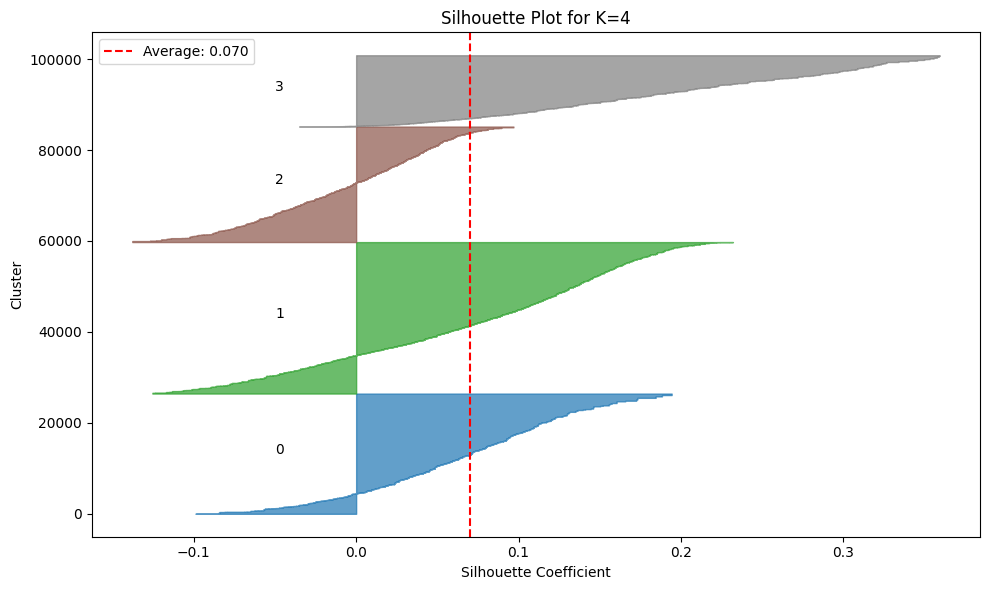


Fitting UMAP...


C:\Users\Beckh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


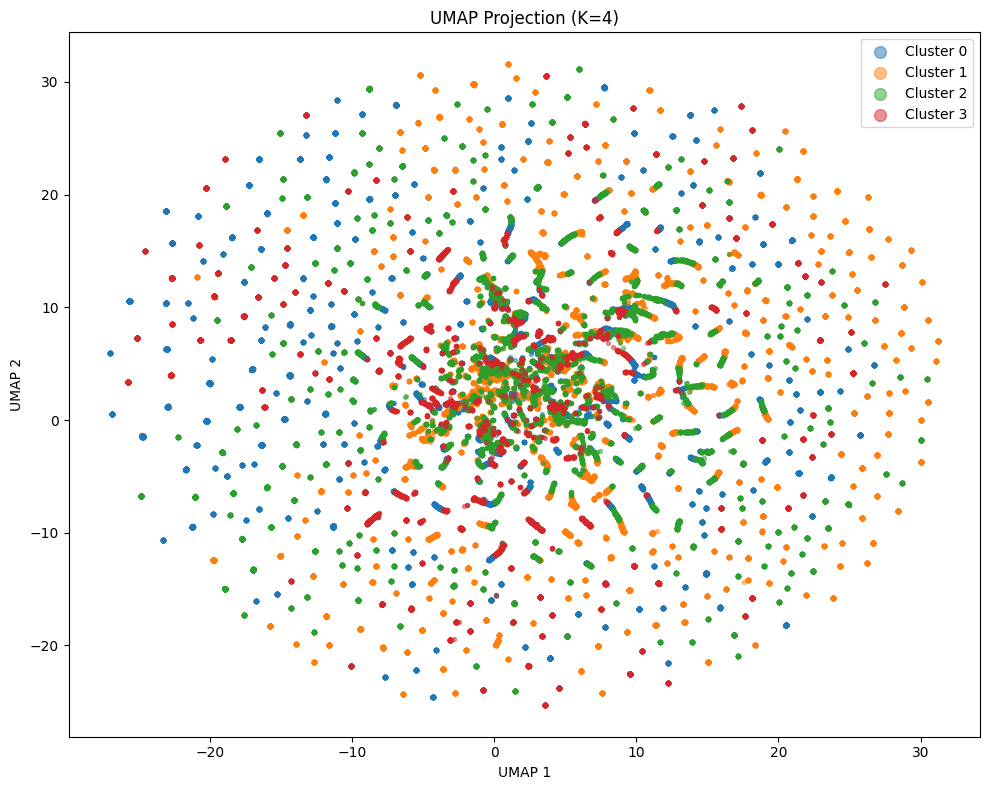


CLUSTER PROFILE FOR K=4

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 26,431 ( 26.2%)
Cluster 1: 33,301 ( 33.0%)
Cluster 2: 25,397 ( 25.2%)
Cluster 3: 15,669 ( 15.5%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        26431  56.72   56.0
1        33301  23.97   24.0
2        25397  39.90   40.0
3        15669  77.27   76.0

3. POLICE INVOLVEMENT
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.990                   0.010
1                        0.981                   0.019
2                        0.981                   0.019
3                        0.998                   0.002

4. WEEKEND
--------------------------------------------------
         Weekend=Weekday  Weekend=Weekend
cluster       

In [29]:
labels_4_reduced, model_4_reduced, profile_4_reduced, cat_4_reduced, sil_4_reduced = run_kprototypes_analysis(
    k=4, X_kproto=X_kproto_reduced, categorical_indices=categorical_indices_reduced,
    df=df, df_cluster=df_cluster_reduced, pre=pre_reduced
)


## k = 5


ANALYSIS FOR K=5
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 19316, ncost: 5610939.863997449
Run: 1, iteration: 2/100, moves: 11958, ncost: 5324736.536726476
Run: 1, iteration: 3/100, moves: 5540, ncost: 5243139.269681597
Run: 1, iteration: 4/100, moves: 2937, ncost: 5215037.225607564
Run: 1, iteration: 5/100, moves: 214, ncost: 5214860.516672247
Run: 1, iteration: 6/100, moves: 0, ncost: 5214860.516672247
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 20579, ncost: 5993706.010580618
Run: 2, iteration: 2/100, moves: 16061, ncost: 5391721.907538188
Run: 2, iteration: 3/100, moves: 10747, ncost: 5239038.647163565
Run: 2, iteration: 4/100, moves: 4471, ncost: 5197873.630342128
Run: 2, iteration: 5/100, moves: 2124, ncost: 5185757.710081358
Run: 2, iteration: 6/100, moves: 428, ncost: 5183627.374770926
Run: 2, iteration: 7/100, moves: 0, ncost: 5183627.374

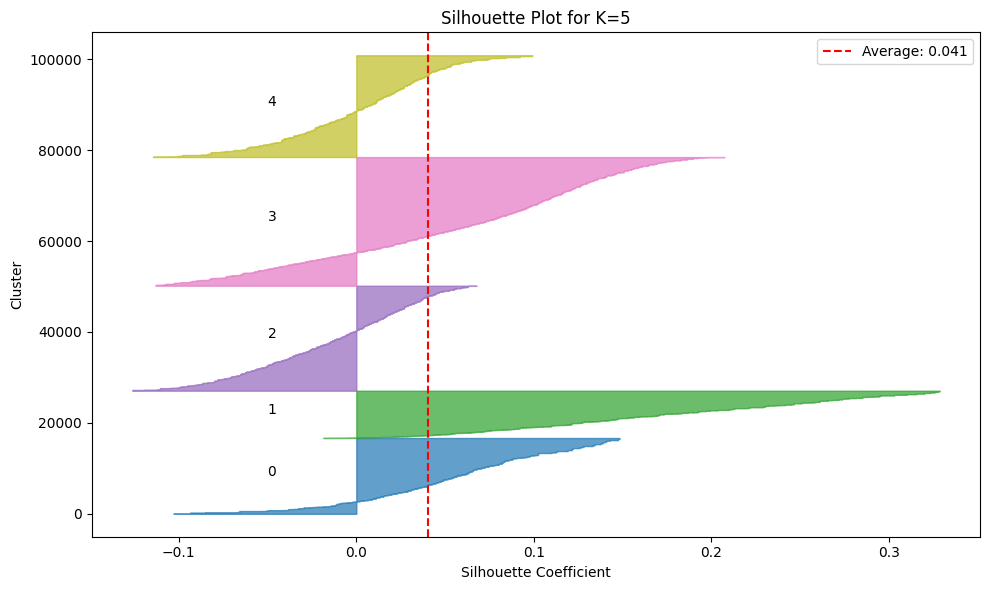


Fitting UMAP...


C:\Users\Beckh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


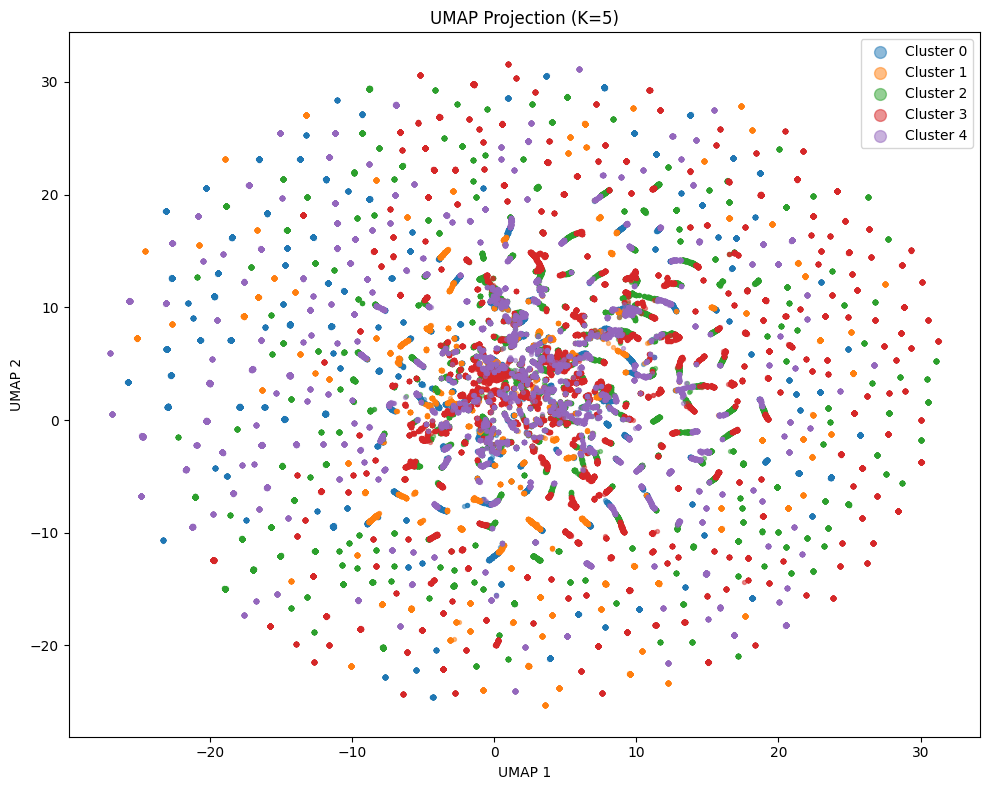


CLUSTER PROFILE FOR K=5

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 16,668 ( 16.5%)
Cluster 1: 10,385 ( 10.3%)
Cluster 2: 23,080 ( 22.9%)
Cluster 3: 28,283 ( 28.1%)
Cluster 4: 22,382 ( 22.2%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        16668  64.11   64.0
1        10385  81.27   81.0
2        23080  35.94   36.0
3        28283  22.80   23.0
4        22382  50.69   51.0

3. POLICE INVOLVEMENT
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.994                   0.006
1                        0.999                   0.001
2                        0.980                   0.020
3                        0.981                   0.019
4                        0.987                   0.013

4. WEEK

In [30]:
labels_5_reduced, model_5_reduced, profile_5_reduced, cat_5_reduced, sil_5_reduced = run_kprototypes_analysis(
    k=5, X_kproto=X_kproto_reduced, categorical_indices=categorical_indices_reduced,
    df=df, df_cluster=df_cluster_reduced, pre=pre_reduced
)

## Comparison: Full vs Reduced Features

In [33]:
print(f"\n{'='*80}")
print("COMPARISON: FULL FEATURES vs REDUCED FEATURES")
print(f"{'='*80}")

# Calculate metrics for full features
df_pre_full = pre.fit_transform(df_cluster)
db_4_full = davies_bouldin_score(df_pre_full, labels_4)
db_5_full = davies_bouldin_score(df_pre_full, labels_5)
ch_4_full = calinski_harabasz_score(df_pre_full, labels_4)
ch_5_full = calinski_harabasz_score(df_pre_full, labels_5)

# Calculate metrics for reduced features
df_pre_reduced = pre_reduced.fit_transform(df_cluster_reduced)
db_4_reduced = davies_bouldin_score(df_pre_reduced, labels_4_reduced)
db_5_reduced = davies_bouldin_score(df_pre_reduced, labels_5_reduced)
ch_4_reduced = calinski_harabasz_score(df_pre_reduced, labels_4_reduced)
ch_5_reduced = calinski_harabasz_score(df_pre_reduced, labels_5_reduced)

print(f"\n{'Metric':<25} {'K=4 Full':>12} {'K=4 Reduced':>12} {'K=5 Full':>12} {'K=5 Reduced':>12}")
print("-" * 80)
print(f"{'Features':<25} {len(encoded_categorical):>12} {len(encoded_categorical_reduced):>12} {len(encoded_categorical):>12} {len(encoded_categorical_reduced):>12}")
print(f"{'Cost':<25} {model_4.cost_:>12.0f} {model_4_reduced.cost_:>12.0f} {model_5.cost_:>12.0f} {model_5_reduced.cost_:>12.0f}")
print(f"{'Davies-Bouldin':<25} {db_4_full:>12.4f} {db_4_reduced:>12.4f} {db_5_full:>12.4f} {db_5_reduced:>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_4_full:>12.2f} {ch_4_reduced:>12.2f} {ch_5_full:>12.2f} {ch_5_reduced:>12.2f}")
print(f"{'Silhouette':<25} {sil_4:>12.4f} {sil_4_reduced:>12.4f} {sil_5:>12.4f} {sil_5_reduced:>12.4f}")

print(f"\n{'='*80}")
print("METRIC INTERPRETATION:")
print("-" * 80)
print("Cost: Lower is better (but not directly comparable between full/reduced)")
print("Davies-Bouldin: Lower is better")
print("Calinski-Harabasz: Higher is better")
print("Silhouette: Higher is better (-1 to 1)")
print(f"{'='*80}")


COMPARISON: FULL FEATURES vs REDUCED FEATURES

Metric                        K=4 Full  K=4 Reduced     K=5 Full  K=5 Reduced
--------------------------------------------------------------------------------
Features                            36           27           36           27
Cost                           7426900      6158071      6463256      5178510
Davies-Bouldin                  3.6642       3.0411       4.5651       3.6374
Calinski-Harabasz             10834.01     15646.56      8411.64     12225.96
Silhouette                      0.0446       0.0700       0.0242       0.0406

METRIC INTERPRETATION:
--------------------------------------------------------------------------------
Cost: Lower is better (but not directly comparable between full/reduced)
Davies-Bouldin: Lower is better
Calinski-Harabasz: Higher is better
Silhouette: Higher is better (-1 to 1)


## Heatmap

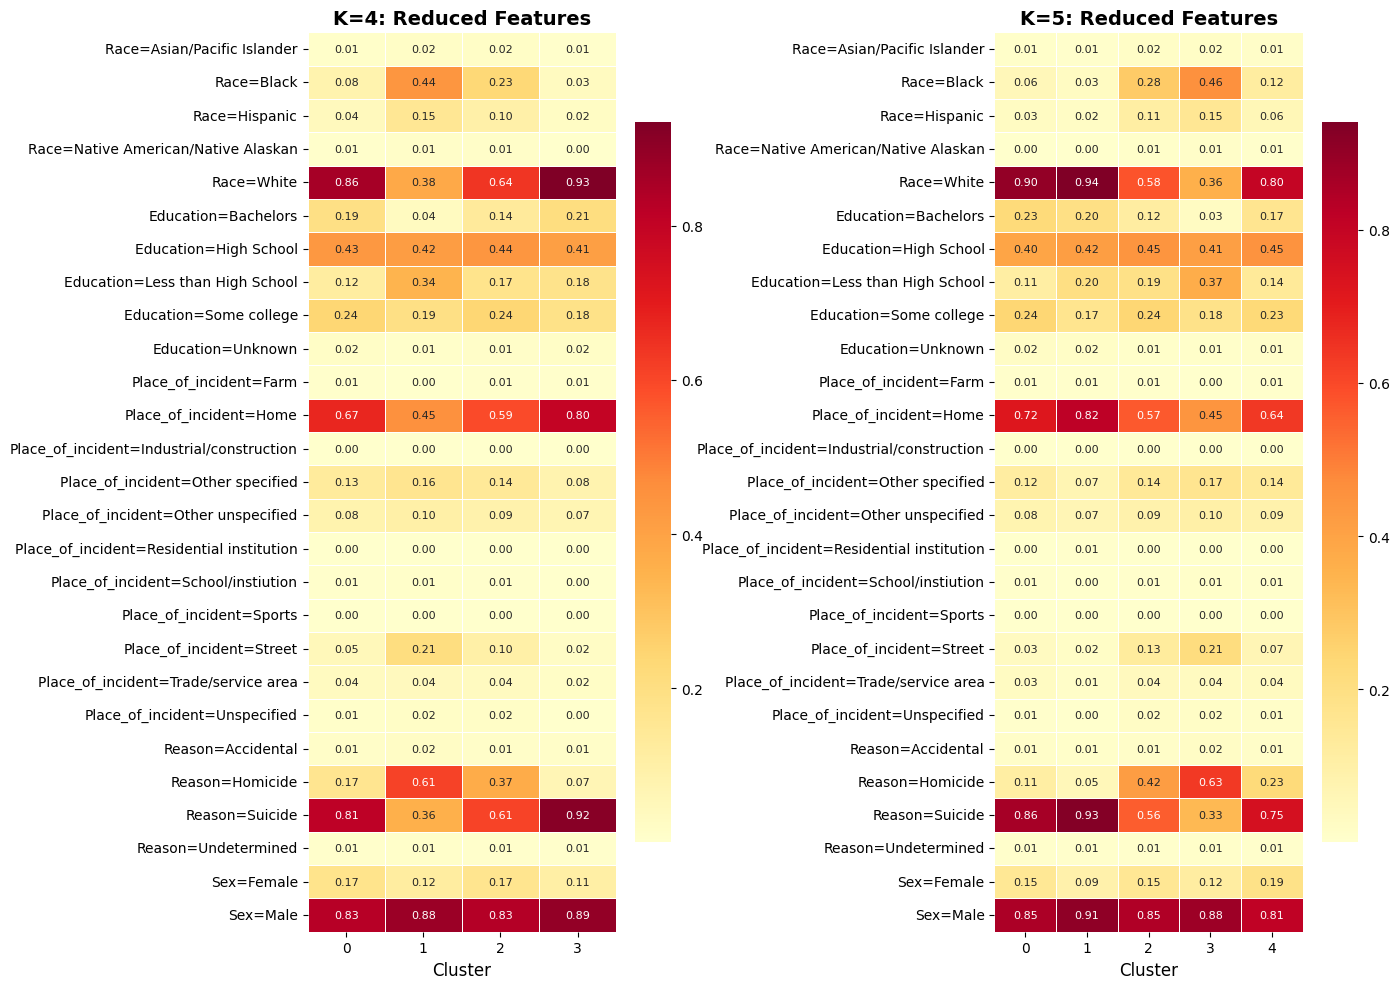

In [35]:
# Filter out the removed features from the cat_summary
cols_to_keep = [col for col in cat_4_reduced.columns 
                if not any(x in col for x in ['Day_of_week', 'Weekend', 'Police_involvement'])]

cat_4_reduced_filtered = cat_4_reduced[cols_to_keep]
cat_5_reduced_filtered = cat_5_reduced[cols_to_keep]

# Use filtered versions for heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

sns.heatmap(cat_4_reduced_filtered.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[0], annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('K=4: Reduced Features', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('')

sns.heatmap(cat_5_reduced_filtered.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[1], annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('K=5: Reduced Features', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()